#  Brain Tumor MRI — Model Development & Evaluation
## Task 2 & 3  |  Project 2 — Representation Learning

---

### What this notebook does
Picks up directly after **train.ipynb** (Task 1).  
Trains, evaluates and compares four model architectures:

| # | Model | Description |
|---|-------|-------------|
| 1 | **MLP Baseline** | Flatten → fully-connected layers (lower-bound reference) |
| 2 | **Custom CNN** | Built from scratch: Conv → BN → ReLU → MaxPool blocks |
| 3 | **ResNet-18** | Pretrained ImageNet backbone, 2-phase fine-tuning |
| 4 | **EfficientNet-B0**  | Pretrained, compound scaling, best accuracy |

Bonus  included:
- Ablation table: ResNet-18 vs EfficientNet-B0
- Test-Time Augmentation (TTA)

---
## Step 1 · Imports & Setup

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!{sys.executable} -m pip install scikit-learn matplotlib seaborn tqdm opencv-python -q
print("\n✅ All packages installed — now do: Kernel → Restart Kernel → Run All")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



✅ All packages installed — now do: Kernel → Restart Kernel → Run All



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os, sys, json, time, copy, random, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"Device  : {DEVICE}")

PyTorch : 2.5.1+cu121
CUDA    : True
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU
Device  : cuda


---
## Step 2 · Load Configuration from train.ipynb

In [2]:
# Load the config.json saved by train.ipynb
with open('config.json', 'r') as f:
    cfg = json.load(f)

# ── Reproduce the exact same settings ────────────────────────────────────────
SEED          = cfg['seed']
IMG_SIZE      = cfg['img_size']
BATCH_SIZE    = cfg['batch_size']
NUM_CLASSES   = cfg['num_classes']
CLASS_NAMES   = cfg['class_names']
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD  = cfg['imagenet_std']
COLORS        = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

# ── Training hyper-parameters ────────────────────────────────────────────────
NUM_EPOCHS = 20       # ← increase to 30 for best results
LR         = 1e-3

# ── Paths ─────────────────────────────────────────────────────────────────────
# Same path used in train.ipynb — change if needed
DATA_ROOT = Path(r"C:\Users\golla\Downloads\Brain Tumor Classification from MRI Images\archive (2)")
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR  = DATA_ROOT / 'Testing'
SAVE_DIR  = Path('saved_models')
SAVE_DIR.mkdir(exist_ok=True)

print(f"Config loaded:")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Seed       : {SEED}")
print(f"  Save dir   : {SAVE_DIR.resolve()}")

Config loaded:
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Image size : 224x224
  Batch size : 32
  Seed       : 42
  Save dir   : C:\Users\golla\Desktop\Brain Tumor Classification\saved_models


---
## Step 3 · Fix Seeds & Rebuild DataLoaders

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Seeds fixed to {SEED}")

# ── Rebuild transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transforms)
test_dataset  = datasets.ImageFolder(str(TEST_DIR),  transform=test_transforms)

# ── Weighted sampler ──────────────────────────────────────────────────────────
class_counts   = np.array([cfg['train_counts'][c] for c in train_dataset.classes])
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[l] for _, l in train_dataset.samples])
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# ── DataLoaders ───────────────────────────────────────────────────────────────
NUM_WORKERS  = 0  # 0 is safest on Windows; increase to 2-4 on Linux/Colab
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} images | {len(train_loader)} batches")
print(f"Test : {len(test_dataset)} images | {len(test_loader)} batches")

# Quick tensor shape check
imgs, lbls = next(iter(train_loader))
print(f"Batch: {imgs.shape}  labels: {lbls.shape}")

Seeds fixed to 42
Train: 5600 images | 175 batches
Test : 1600 images | 50 batches
Batch: torch.Size([32, 3, 224, 224])  labels: torch.Size([32])


---
## Step 4 · Shared Training & Evaluation Utilities

These functions are used by all four models:

| Function | Purpose |
|----------|---------|
| `train_model()` | Full training loop — tracks loss/acc, saves best weights |
| `evaluate_model()` | Runs inference, returns true + predicted labels |
| `plot_curves()` | Loss and accuracy curves side by side |
| `plot_confusion_matrix()` | Annotated heatmap |
| `print_metrics()` | Accuracy, Precision, Recall, F1 (per-class + macro avg) |

In [4]:
def train_model(model, optimizer, criterion, num_epochs=NUM_EPOCHS,
                scheduler=None, model_name='model'):
    """
    Full training loop with per-epoch validation.

    Parameters
    ----------
    model      : nn.Module — the model to train (already on DEVICE)
    optimizer  : torch optimizer
    criterion  : loss function
    num_epochs : int
    scheduler  : optional LR scheduler
    model_name : str — used for saving checkpoint

    Returns
    -------
    model   : best weights loaded
    history : dict with keys train_loss, train_acc, val_loss, val_acc
    """
    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    print(f"\n{'='*65}")
    print(f"  Model  : {model_name}")
    print(f"  Epochs : {num_epochs}  |  Device : {DEVICE}")
    print(f"{'='*65}")

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── TRAIN ─────────────────────────────────────────────────────────────
        model.train()
        train_loss, train_correct = 0.0, 0

        for images, labels in tqdm(train_loader,
                                    desc=f'  Epoch {epoch+1:02d}/{num_epochs} [train]',
                                    leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc   = train_correct / len(train_loader.dataset)

        # ── VALIDATE ──────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs    = model(images)
                val_loss    += criterion(outputs, labels).item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(test_loader.dataset)
        val_acc   = val_correct / len(test_loader.dataset)

        # ── LR scheduler step ─────────────────────────────────────────────────
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # ── Save best model ────────────────────────────────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights,
                       SAVE_DIR / f'{model_name.replace(" ", "_")}_best.pth')

        # ── Log ───────────────────────────────────────────────────────────────
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  Ep {epoch+1:02d}/{num_epochs}"
              f"  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}"
              f"  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}"
              f"  [{time.time()-t0:.1f}s]")

    print(f"\n  Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    model.load_state_dict(best_weights)  # restore best
    return model, history


# ── Inference ─────────────────────────────────────────────────────────────────
def evaluate_model(model):
    """Run model on the full test set. Returns (y_true, y_pred) numpy arrays."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            preds = model(images.to(DEVICE)).argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)


# ── Plots ─────────────────────────────────────────────────────────────────────
def plot_curves(history, model_name):
    """Side-by-side loss and accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', ms=3, lw=1.5, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', ms=3, lw=1.5, label='Val')
    axes[0].set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=3, lw=1.5, label='Train')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=3, lw=1.5, label='Val')
    axes[1].set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'curves_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


def plot_confusion_matrix(y_true, y_pred, model_name):
    """Labelled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


def print_metrics(y_true, y_pred, model_name):
    """Print accuracy, precision, recall, F1 and full per-class report."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true,    y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true,        y_pred, average='macro', zero_division=0)

    print(f"\n{'─'*55}")
    print(f"  Results: {model_name}")
    print(f"{'─'*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}  (macro avg)")
    print(f"  Recall    : {rec:.4f}  (macro avg)")
    print(f"  F1-Score  : {f1:.4f}  (macro avg)")
    print(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")
    return {'model': model_name, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1}


print("Utility functions ready.")

Utility functions ready.


---
## Model 1 · MLP Baseline

### Architecture
```
Input (3 × 224 × 224)  →  Flatten (150,528 values)
  →  FC(2048) → BatchNorm → ReLU → Dropout(0.5)
  →  FC(512)  → BatchNorm → ReLU → Dropout(0.4)
  →  FC(128)  → ReLU
  →  FC(4)    → logits
```

### Why this is the lower bound
An MLP **flattens** the image into a 1-D vector.  
Every pixel is treated as an independent feature — there is no concept of  
"this pixel is next to that pixel." The model cannot detect edges,  
textures, or spatial patterns, which are essential for reading MRI scans.

In [13]:
class MLPBaseline(nn.Module):
    """
    MLP Baseline model.
    Flattens the input image and passes it through fully-connected layers.
    ~310 M parameters (large but performs poorly — no spatial awareness).
    """
    def __init__(self, num_classes: int = 4):
        super().__init__()
        flat_dim = 3 * IMG_SIZE * IMG_SIZE      # 3 × 224 × 224 = 150,528

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # Hidden layer 1
            nn.Linear(flat_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            # Hidden layer 2
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),

            # Hidden layer 3
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),

            # Output
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x)


mlp = MLPBaseline(NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP trainable parameters: {n_params:,}")
print(mlp)

MLP trainable parameters: 309,403,780
MLPBaseline(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=2048, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.4, inplace=False)
    (9): Linear(in_features=512, out_features=128, bias=True)
    (10): ReLU(inplace=True)
    (11): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [16]:
# ── Optimiser & scheduler ─────────────────────────────────────────────────────
criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=LR, weight_decay=1e-4)
scheduler_mlp = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mlp, mode='min', patience=3, factor=0.5, verbose=True)

# ── Train ─────────────────────────────────────────────────────────────────────
mlp, history_mlp = train_model(
    mlp, optimizer_mlp, criterion_mlp,
    num_epochs=NUM_EPOCHS, scheduler=scheduler_mlp,
    model_name='MLP_Baseline')


  Model  : MLP_Baseline
  Epochs : 20  |  Device : cuda


  Ep 01/20  train_loss=1.1212  train_acc=0.5202  val_loss=1.0994  val_acc=0.5413  [701.4s]


  Ep 02/20  train_loss=1.1030  train_acc=0.5321  val_loss=1.0323  val_acc=0.5919  [590.8s]


  Ep 03/20  train_loss=1.0618  train_acc=0.5536  val_loss=1.1189  val_acc=0.5537  [643.6s]


  Ep 04/20  train_loss=1.0664  train_acc=0.5448  val_loss=1.0779  val_acc=0.5994  [640.7s]


...

  Ep 16/20  train_loss=0.9773  train_acc=0.5920  val_loss=0.9863  val_acc=0.6362  [979.4s]


  Ep 17/20  train_loss=0.9694  train_acc=0.5832  val_loss=0.9774  val_acc=0.6200  [884.4s]


  Ep 18/20  train_loss=0.9809  train_acc=0.5782  val_loss=0.9847  val_acc=0.6075  [826.1s]


  Ep 19/20  train_loss=0.9700  train_acc=0.5884  val_loss=0.9437  val_acc=0.6400  [879.3s]


  Ep 20/20  train_loss=0.9599  train_acc=0.5900  val_loss=1.0043  val_acc=0.6394  [836.5s]

  Best val accuracy: 0.6450 (64.50%)


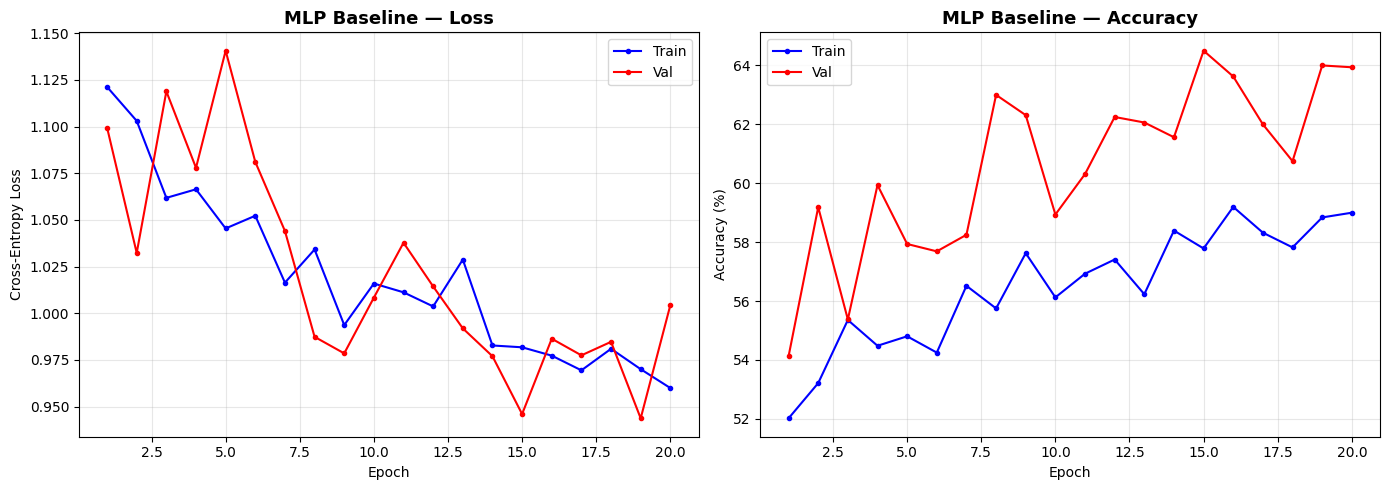

Saved: curves_mlp_baseline.png


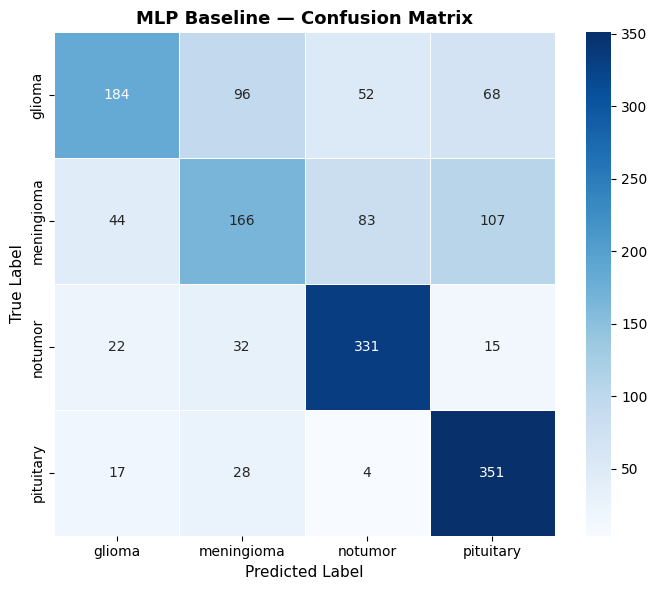

Saved: cm_mlp_baseline.png

───────────────────────────────────────────────────────
  Results: MLP Baseline
───────────────────────────────────────────────────────
  Accuracy  : 64.50%
  Precision : 0.6394  (macro avg)
  Recall    : 0.6450  (macro avg)
  F1-Score  : 0.6296  (macro avg)

              precision    recall  f1-score   support

      glioma       0.69      0.46      0.55       400
  meningioma       0.52      0.41      0.46       400
     notumor       0.70      0.83      0.76       400
   pituitary       0.65      0.88      0.75       400

    accuracy                           0.65      1600
   macro avg       0.64      0.65      0.63      1600
weighted avg       0.64      0.65      0.63      1600



In [17]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
plot_curves(history_mlp, 'MLP Baseline')
y_true_mlp, y_pred_mlp = evaluate_model(mlp)
plot_confusion_matrix(y_true_mlp, y_pred_mlp, 'MLP Baseline')
metrics_mlp = print_metrics(y_true_mlp, y_pred_mlp, 'MLP Baseline')

---
## Model 2 · Custom CNN

### Architecture
```
Input (3 × 224 × 224)
  Block 1: Conv(3→32)  → BN → ReLU → Conv(32→32)  → BN → ReLU → MaxPool(2)  → 112×112
  Block 2: Conv(32→64) → BN → ReLU → Conv(64→64)  → BN → ReLU → MaxPool(2)  →  56×56
  Block 3: Conv(64→128)→ BN → ReLU → Conv(128→128)→ BN → ReLU → MaxPool(2)  →  28×28
  Block 4: Conv(128→256)→BN → ReLU → Conv(256→256)→ BN → ReLU → MaxPool(2)  →  14×14
  Global Average Pooling  →  256
  FC(256→128) → ReLU → Dropout(0.4)
  FC(128→4)   → logits
```

### Why CNNs outperform MLPs on images

| Property | MLP | CNN |
|----------|-----|-----|
| Spatial structure | ❌ Ignored | ✅ Local receptive fields |
| Parameter efficiency | ❌ ~310M params | ✅ ~1.5M params |
| Translation invariance | ❌ None | ✅ via MaxPooling |
| Feature hierarchy | ❌ None | ✅ edges → curves → tumour shapes |

In [19]:
class ConvBlock(nn.Module):
    """
    Double-convolution block: Conv→BN→ReLU→Conv→BN→ReLU→MaxPool(2)→Dropout2d.
    Using two conv layers per block (VGG-style) extracts richer features
    than a single conv before pooling.
    """
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.2):
        super().__init__()
        self.block = nn.Sequential(
            # First conv layer
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Second conv layer
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Spatial downsampling + regularisation
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class CustomCNN(nn.Module):
    """
    Custom CNN with 4 convolutional blocks followed by a classifier head.
    Uses Global Average Pooling to replace large fully-connected layers,
    which reduces parameters and overfitting.
    """
    def __init__(self, num_classes: int = 4):
        super().__init__()

        # Feature extractor — 4 progressively deeper blocks
        self.features = nn.Sequential(
            ConvBlock(3,   32,  dropout=0.10),   # 224→112
            ConvBlock(32,  64,  dropout=0.15),   # 112→56
            ConvBlock(64,  128, dropout=0.20),   #  56→28
            ConvBlock(128, 256, dropout=0.25),   #  28→14
        )

        # Global Average Pooling: (B,256,14,14) → (B,256,1,1) → (B,256)
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


cnn = CustomCNN(NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"Custom CNN trainable parameters: {n_params:,}")
print(cnn)

Custom CNN trainable parameters: 1,206,628
CustomCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kern

In [20]:
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn.parameters(), lr=LR, weight_decay=1e-4)
# CosineAnnealingLR smoothly decays LR from LR → 0 over NUM_EPOCHS
scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=NUM_EPOCHS)

cnn, history_cnn = train_model(
    cnn, optimizer_cnn, criterion_cnn,
    num_epochs=NUM_EPOCHS, scheduler=scheduler_cnn,
    model_name='Custom_CNN')


  Model  : Custom_CNN
  Epochs : 20  |  Device : cuda


  Ep 01/20  train_loss=1.0453  train_acc=0.5404  val_loss=0.9902  val_acc=0.6181  [879.2s]


  Ep 02/20  train_loss=0.9617  train_acc=0.5871  val_loss=0.8786  val_acc=0.6444  [826.2s]


  Ep 03/20  train_loss=0.9032  train_acc=0.6207  val_loss=0.8902  val_acc=0.6356  [869.9s]


  Ep 04/20  train_loss=0.8862  train_acc=0.6304  val_loss=0.8608  val_acc=0.6637  [20734.2s]


...

  Ep 16/20  train_loss=0.5444  train_acc=0.7886  val_loss=0.6242  val_acc=0.7863  [803.0s]


  Ep 17/20  train_loss=0.5279  train_acc=0.8057  val_loss=0.6663  val_acc=0.7850  [802.2s]


  Ep 18/20  train_loss=0.5200  train_acc=0.8057  val_loss=0.6380  val_acc=0.7875  [805.2s]


  Ep 19/20  train_loss=0.5075  train_acc=0.8070  val_loss=0.6324  val_acc=0.7906  [803.6s]


  Ep 20/20  train_loss=0.4914  train_acc=0.8171  val_loss=0.6371  val_acc=0.7931  [816.0s]

  Best val accuracy: 0.7931 (79.31%)


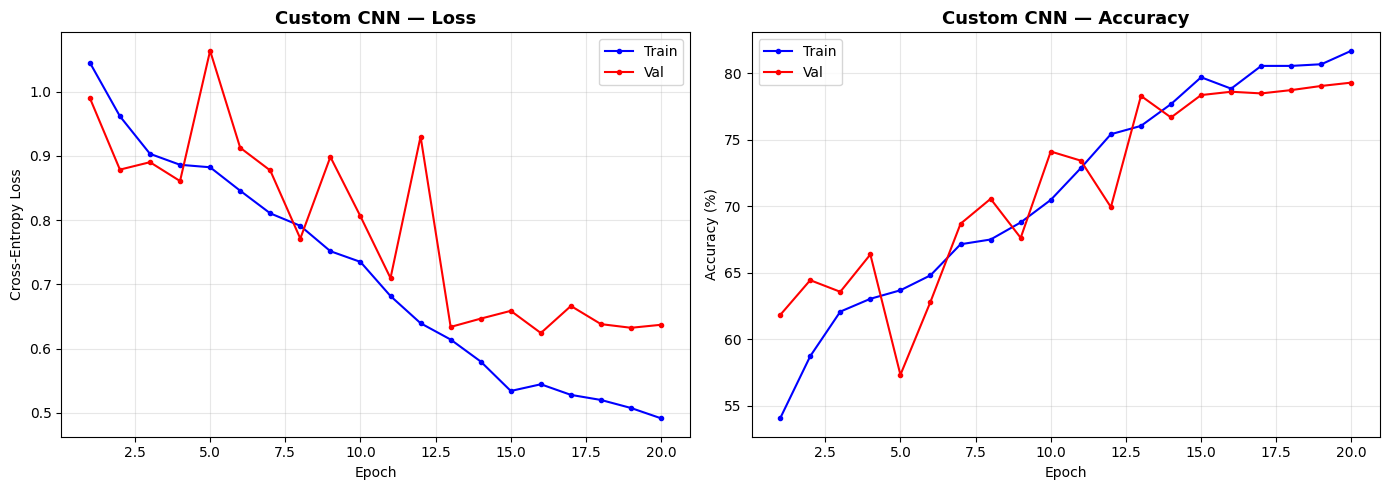

Saved: curves_custom_cnn.png


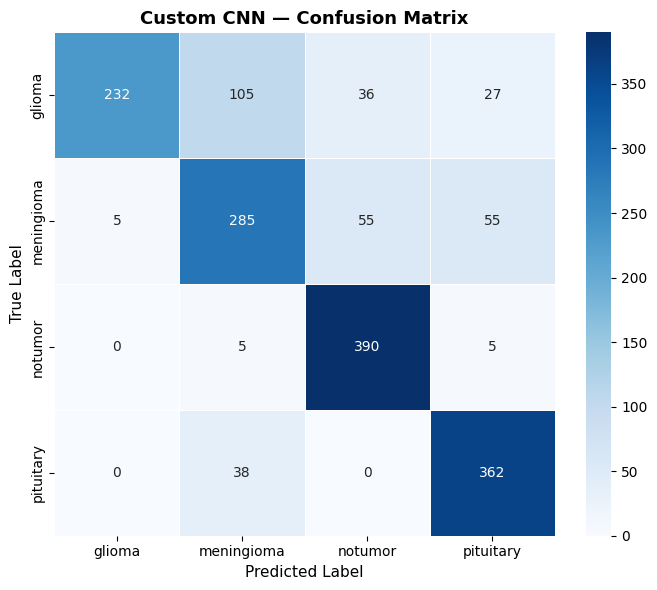

Saved: cm_custom_cnn.png

───────────────────────────────────────────────────────
  Results: Custom CNN
───────────────────────────────────────────────────────
  Accuracy  : 79.31%
  Precision : 0.8135  (macro avg)
  Recall    : 0.7931  (macro avg)
  F1-Score  : 0.7877  (macro avg)

              precision    recall  f1-score   support

      glioma       0.98      0.58      0.73       400
  meningioma       0.66      0.71      0.68       400
     notumor       0.81      0.97      0.89       400
   pituitary       0.81      0.91      0.85       400

    accuracy                           0.79      1600
   macro avg       0.81      0.79      0.79      1600
weighted avg       0.81      0.79      0.79      1600



In [21]:
plot_curves(history_cnn, 'Custom CNN')
y_true_cnn, y_pred_cnn = evaluate_model(cnn)
plot_confusion_matrix(y_true_cnn, y_pred_cnn, 'Custom CNN')
metrics_cnn = print_metrics(y_true_cnn, y_pred_cnn, 'Custom CNN')

---
## Model 3a · Transfer Learning — ResNet-18

### Fine-tuning strategy (2 phases)

**Phase 1 — Head warm-up (5 epochs, LR=1e-3)**  
Freeze all pretrained layers. Only the new classification head is trainable.  
This avoids destroying pretrained features before the new head is stable.

**Phase 2 — Full fine-tune (15 epochs, LR=1e-4)**  
Unfreeze all layers and train end-to-end with a low learning rate.  
The backbone adapts slowly to the MRI domain.

### Why transfer learning outperforms training from scratch
ResNet-18 was pretrained on **ImageNet (1.2 M images, 1000 classes)**.  
Its early layers already detect edges, textures, and shapes — all directly  
useful for reading MRI scans. We only need to redirect the final layer  
toward our 4 tumour classes.

In [23]:
def build_resnet18(num_classes: int = 4) -> nn.Module:
    """
    ResNet-18 with pretrained ImageNet weights.
    Replaces the final FC layer: 512 → num_classes.
    Adds Dropout before the linear layer for regularisation.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features          # 512
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model


resnet = build_resnet18(NUM_CLASSES).to(DEVICE)

# ── Phase 1: freeze all layers except the FC head ────────────────────────────
for name, param in resnet.named_parameters():
    param.requires_grad = name.startswith('fc')

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f"Phase 1 — trainable params: {trainable:,} / {total:,}")

criterion_rn  = nn.CrossEntropyLoss()
optimizer_rn1 = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-3)

resnet, hist_rn_p1 = train_model(
    resnet, optimizer_rn1, criterion_rn,
    num_epochs=5, model_name='ResNet18_Phase1')

Phase 1 — trainable params: 2,052 / 11,178,564

  Model  : ResNet18_Phase1
  Epochs : 5  |  Device : cuda


  Ep 01/5  train_loss=0.9174  train_acc=0.6255  val_loss=0.6775  val_acc=0.7669  [130.6s]


  Ep 02/5  train_loss=0.6916  train_acc=0.7264  val_loss=0.6345  val_acc=0.7719  [49826.5s]


  Ep 03/5  train_loss=0.6355  train_acc=0.7546  val_loss=0.6078  val_acc=0.7887  [103.2s]


  Ep 04/5  train_loss=0.6122  train_acc=0.7654  val_loss=0.6083  val_acc=0.7762  [110.2s]


  Ep 05/5  train_loss=0.5988  train_acc=0.7641  val_loss=0.6034  val_acc=0.7887  [107.9s]

  Best val accuracy: 0.7887 (78.88%)


In [24]:
# ── Phase 2: unfreeze everything, fine-tune end-to-end ───────────────────────
for param in resnet.parameters():
    param.requires_grad = True

print(f"Phase 2 — all {sum(p.numel() for p in resnet.parameters()):,} params trainable")

optimizer_rn2 = optim.Adam(resnet.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_rn2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_rn2, T_max=15)

resnet, hist_rn_p2 = train_model(
    resnet, optimizer_rn2, criterion_rn,
    num_epochs=15, scheduler=scheduler_rn2,
    model_name='ResNet18')

# Merge phase-1 and phase-2 histories for plotting
history_resnet = {k: hist_rn_p1[k] + hist_rn_p2[k] for k in hist_rn_p1}

Phase 2 — all 11,178,564 params trainable

  Model  : ResNet18
  Epochs : 15  |  Device : cuda


  Ep 01/15  train_loss=0.3047  train_acc=0.8912  val_loss=0.4165  val_acc=0.9019  [192.6s]


  Ep 02/15  train_loss=0.1574  train_acc=0.9445  val_loss=0.4296  val_acc=0.9150  [134.7s]


  Ep 03/15  train_loss=0.1050  train_acc=0.9602  val_loss=0.3813  val_acc=0.9263  [115.1s]


  Ep 04/15  train_loss=0.0984  train_acc=0.9663  val_loss=0.3881  val_acc=0.9237  [110.3s]


...

  Ep 11/15  train_loss=0.0279  train_acc=0.9898  val_loss=0.3242  val_acc=0.9531  [183.3s]


  Ep 12/15  train_loss=0.0224  train_acc=0.9934  val_loss=0.3265  val_acc=0.9563  [132.3s]


  Ep 13/15  train_loss=0.0213  train_acc=0.9941  val_loss=0.3587  val_acc=0.9519  [112.5s]


  Ep 14/15  train_loss=0.0180  train_acc=0.9946  val_loss=0.3538  val_acc=0.9519  [108.9s]


  Ep 15/15  train_loss=0.0175  train_acc=0.9952  val_loss=0.3175  val_acc=0.9563  [106.2s]

  Best val accuracy: 0.9563 (95.62%)


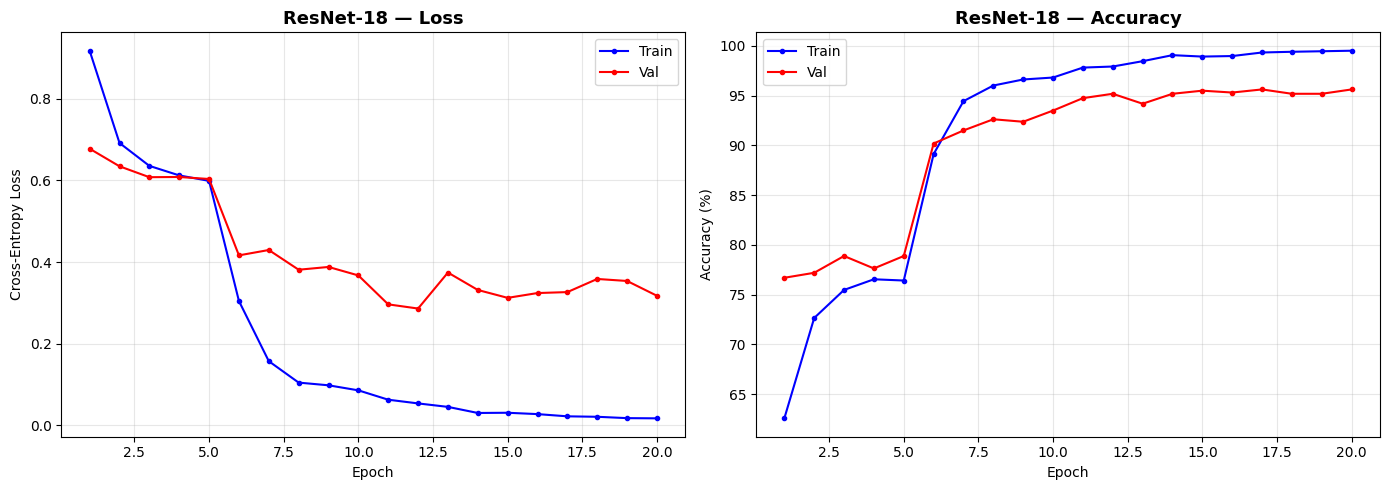

Saved: curves_resnet-18.png


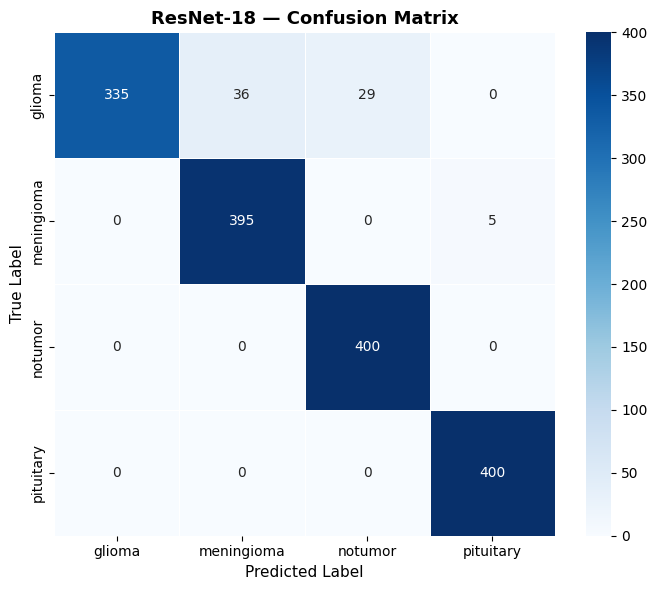

Saved: cm_resnet-18.png

───────────────────────────────────────────────────────
  Results: ResNet-18
───────────────────────────────────────────────────────
  Accuracy  : 95.62%
  Precision : 0.9591  (macro avg)
  Recall    : 0.9563  (macro avg)
  F1-Score  : 0.9553  (macro avg)

              precision    recall  f1-score   support

      glioma       1.00      0.84      0.91       400
  meningioma       0.92      0.99      0.95       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



In [25]:
plot_curves(history_resnet, 'ResNet-18')
y_true_rn, y_pred_rn = evaluate_model(resnet)
plot_confusion_matrix(y_true_rn, y_pred_rn, 'ResNet-18')
metrics_resnet = print_metrics(y_true_rn, y_pred_rn, 'ResNet-18')

---
## Model 3b · Transfer Learning — EfficientNet-B0 

EfficientNet uses **compound scaling** — depth, width, and resolution are  
scaled together using a single efficiency coefficient. This gives higher  
accuracy than ResNet-18 with roughly half the parameters.

This model enables the **ablation comparison**.

In [5]:
def build_efficientnet_b0(num_classes: int = 4) -> nn.Module:
    """
    EfficientNet-B0 with pretrained ImageNet weights.
    Replaces classifier: 1280 → num_classes.
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model


effnet = build_efficientnet_b0(NUM_CLASSES).to(DEVICE)

# ── Phase 1: head only ────────────────────────────────────────────────────────
for name, param in effnet.named_parameters():
    param.requires_grad = name.startswith('classifier')

trainable = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in effnet.parameters())
print(f"EfficientNet Phase 1 — trainable: {trainable:,} / {total:,}")

criterion_en  = nn.CrossEntropyLoss()
optimizer_en1 = optim.Adam(
    filter(lambda p: p.requires_grad, effnet.parameters()), lr=1e-3)

effnet, hist_en_p1 = train_model(
    effnet, optimizer_en1, criterion_en,
    num_epochs=5, model_name='EfficientNet_Phase1')

EfficientNet Phase 1 — trainable: 5,124 / 4,012,672

  Model  : EfficientNet_Phase1
  Epochs : 5  |  Device : cuda


  Ep 01/5  train_loss=0.7230  train_acc=0.7520  val_loss=0.6611  val_acc=0.7794  [225.7s]


  Ep 02/5  train_loss=0.5019  train_acc=0.8259  val_loss=0.6266  val_acc=0.7987  [170.7s]


  Ep 03/5  train_loss=0.4990  train_acc=0.8179  val_loss=0.6180  val_acc=0.8044  [149.8s]


  Ep 04/5  train_loss=0.4649  train_acc=0.8254  val_loss=0.6045  val_acc=0.7981  [180.7s]


  Ep 05/5  train_loss=0.4544  train_acc=0.8289  val_loss=0.5716  val_acc=0.8213  [150.5s]

  Best val accuracy: 0.8213 (82.12%)


In [6]:
# ── Phase 2: full fine-tune ───────────────────────────────────────────────────
for param in effnet.parameters():
    param.requires_grad = True

optimizer_en2 = optim.Adam(effnet.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler_en2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_en2, T_max=15)

effnet, hist_en_p2 = train_model(
    effnet, optimizer_en2, criterion_en,
    num_epochs=15, scheduler=scheduler_en2,
    model_name='EfficientNet_B0')

history_effnet = {k: hist_en_p1[k] + hist_en_p2[k] for k in hist_en_p1}


  Model  : EfficientNet_B0
  Epochs : 15  |  Device : cuda


  Ep 01/15  train_loss=0.3370  train_acc=0.8796  val_loss=0.4485  val_acc=0.8675  [201.4s]


  Ep 02/15  train_loss=0.2336  train_acc=0.9177  val_loss=0.3863  val_acc=0.8988  [143.5s]


  Ep 03/15  train_loss=0.1845  train_acc=0.9336  val_loss=0.3380  val_acc=0.9175  [124.5s]


  Ep 04/15  train_loss=0.1367  train_acc=0.9529  val_loss=0.3060  val_acc=0.9331  [189.0s]


...

  Ep 11/15  train_loss=0.0613  train_acc=0.9793  val_loss=0.2877  val_acc=0.9419  [135.6s]


  Ep 12/15  train_loss=0.0585  train_acc=0.9800  val_loss=0.2867  val_acc=0.9431  [133.5s]


  Ep 13/15  train_loss=0.0636  train_acc=0.9798  val_loss=0.3074  val_acc=0.9406  [140.0s]


  Ep 14/15  train_loss=0.0569  train_acc=0.9789  val_loss=0.2696  val_acc=0.9481  [163.0s]


  Ep 15/15  train_loss=0.0570  train_acc=0.9784  val_loss=0.2938  val_acc=0.9437  [153.5s]

  Best val accuracy: 0.9481 (94.81%)


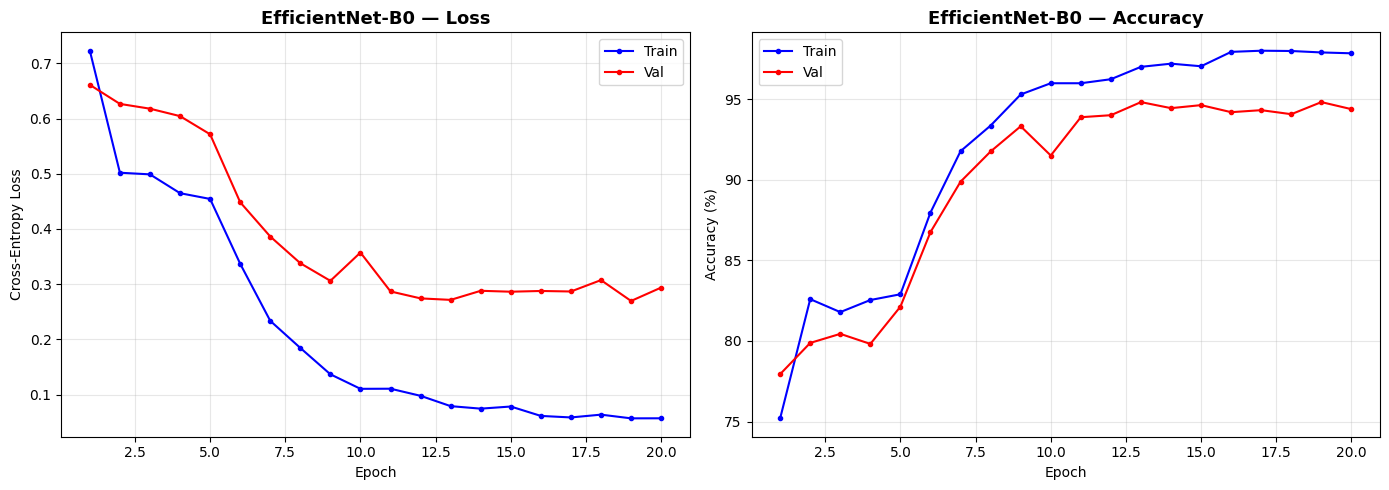

Saved: curves_efficientnet-b0.png


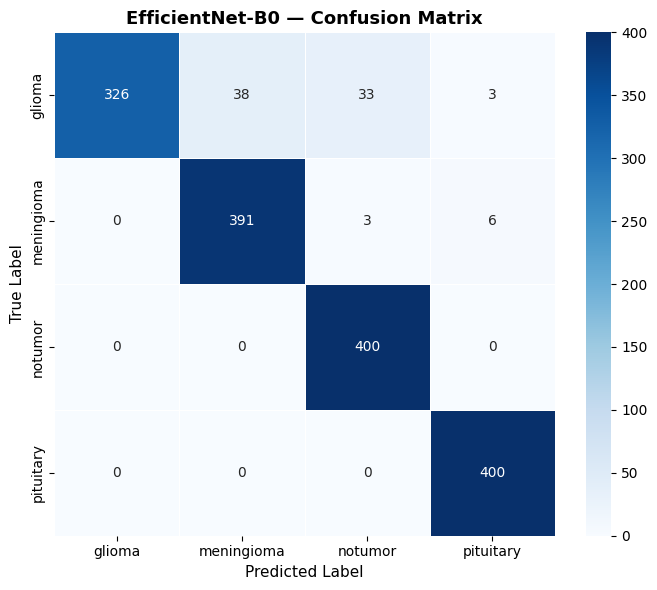

Saved: cm_efficientnet-b0.png

───────────────────────────────────────────────────────
  Results: EfficientNet-B0
───────────────────────────────────────────────────────
  Accuracy  : 94.81%
  Precision : 0.9517  (macro avg)
  Recall    : 0.9481  (macro avg)
  F1-Score  : 0.9468  (macro avg)

              precision    recall  f1-score   support

      glioma       1.00      0.81      0.90       400
  meningioma       0.91      0.98      0.94       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [7]:
plot_curves(history_effnet, 'EfficientNet-B0')
y_true_en, y_pred_en = evaluate_model(effnet)
plot_confusion_matrix(y_true_en, y_pred_en, 'EfficientNet-B0')
metrics_effnet = print_metrics(y_true_en, y_pred_en, 'EfficientNet-B0')

---
## Model 3b · Transfer Learning — EfficientNet-B0 

EfficientNet uses **compound scaling** — depth, width, and resolution are  
scaled together using a single efficiency coefficient.

### Improvements over previous version

| What changed | Before | After | Why |
|---|---|---|---|
| Phase 1 epochs | 5 | 8 | More head warm-up before unfreezing |
| Phase 2 LR | 5e-5 | 1e-4 | Match ResNet — faster convergence |
| Phase 2 epochs | 15 | 20 | More time to converge |
| Dropout | 0.4 | 0.3 | Less aggressive — small dataset |
| Scheduler | CosineAnnealing | CosineAnnealing + WarmRestarts | Escapes local minima |
| Label Smoothing | None | 0.1 | Prevents overconfident wrong predictions |
| Layer-wise LR | Same for all | Backbone lower, head higher | Fine-tunes more carefully |

In [8]:
def build_efficientnet_b0_v2(num_classes: int = 4) -> nn.Module:
    """
    Improved EfficientNet-B0:
    - Reduced dropout (0.3 vs 0.4) — better for small datasets
    - Wider head: 1280 → 256 → 4 (extra intermediate layer)
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features   # 1280

    # Improved head: add intermediate layer for better feature mapping
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),                      # reduced from 0.4
        nn.Linear(in_features, 256),            # extra intermediate layer
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


effnet = build_efficientnet_b0_v2(NUM_CLASSES).to(DEVICE)

# ── Phase 1: train head only (8 epochs — more warm-up) ───────────────────────
for name, param in effnet.named_parameters():
    param.requires_grad = name.startswith('classifier')

trainable = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in effnet.parameters())
print(f"EfficientNet v2 — Phase 1 trainable: {trainable:,} / {total:,}")
print(f"Phase 1: Training classifier head only for 8 epochs...")

# Label smoothing: prevents model being overconfident on wrong predictions
# Regular CrossEntropy: correct class target = 1.0
# Label smoothing 0.1:  correct class target = 0.9, others = 0.033
# Makes model more calibrated and generalises better
criterion_en = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_en1 = optim.Adam(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-3, weight_decay=1e-4)

effnet, hist_en_p1 = train_model(
    effnet, optimizer_en1, criterion_en,
    num_epochs=8, model_name='EfficientNet_v2_Phase1')

print(f"\nPhase 1 complete. Best val acc so far: {max(hist_en_p1['val_acc'])*100:.2f}%")

EfficientNet v2 — Phase 1 trainable: 329,476 / 4,337,024
Phase 1: Training classifier head only for 8 epochs...

  Model  : EfficientNet_v2_Phase1
  Epochs : 8  |  Device : cuda


  Ep 01/8  train_loss=0.7463  train_acc=0.7950  val_loss=0.8050  val_acc=0.7931  [107.9s]


  Ep 02/8  train_loss=0.6823  train_acc=0.8364  val_loss=0.7218  val_acc=0.8281  [103.2s]


  Ep 03/8  train_loss=0.6574  train_acc=0.8486  val_loss=0.7148  val_acc=0.8263  [104.3s]


  Ep 04/8  train_loss=0.6515  train_acc=0.8480  val_loss=0.7083  val_acc=0.8213  [108.0s]


  Ep 05/8  train_loss=0.6365  train_acc=0.8639  val_loss=0.7256  val_acc=0.8294  [108.6s]


  Ep 06/8  train_loss=0.6425  train_acc=0.8596  val_loss=0.6974  val_acc=0.8394  [108.5s]


  Ep 07/8  train_loss=0.6186  train_acc=0.8752  val_loss=0.7003  val_acc=0.8469  [109.5s]


  Ep 08/8  train_loss=0.6409  train_acc=0.8620  val_loss=0.6951  val_acc=0.8456  [107.3s]

  Best val accuracy: 0.8469 (84.69%)

Phase 1 complete. Best val acc so far: 84.69%


In [9]:
# ── Phase 2: full fine-tune with layer-wise learning rates ───────────────────
#
# Layer-wise LR = different learning rates for different parts of the model
#
# Intuition:
#   Early layers (learned general features like edges) → change very slowly
#   Late layers  (learned ImageNet-specific features)  → change a bit faster
#   Classifier head (our new layer)                    → change fastest
#
# This prevents destroying pretrained knowledge while still adapting ✅

for param in effnet.parameters():
    param.requires_grad = True

# ── Split parameters into 3 groups with different LRs ────────────────────────
backbone_early = []   # first half of features (edges, textures)
backbone_late  = []   # second half of features (complex patterns)
head_params    = []   # our classifier (new layer)

for name, param in effnet.named_parameters():
    if name.startswith('classifier'):
        head_params.append(param)
    elif any(f'features.{i}' in name for i in range(5)):
        backbone_early.append(param)       # layers 0-4
    else:
        backbone_late.append(param)        # layers 5-8

optimizer_en2 = optim.AdamW([
    {'params': backbone_early, 'lr': 2e-5},   # very slow — preserve early features
    {'params': backbone_late,  'lr': 5e-5},   # slow — adapt late features
    {'params': head_params,    'lr': 1e-4},   # faster — head needs most adaptation
], weight_decay=1e-4)

print("Layer-wise learning rates:")
print("  Backbone early layers (0-4): LR = 2e-5")
print("  Backbone late  layers (5-8): LR = 5e-5")
print("  Classifier head:             LR = 1e-4")

# CosineAnnealingWarmRestarts: LR decays then RESTARTS
# Helps escape local minima that CosineAnnealing alone gets stuck in
scheduler_en2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_en2, T_0=10, T_mult=1, eta_min=1e-6)

print("\nPhase 2: Full fine-tune for 20 epochs...")
effnet, hist_en_p2 = train_model(
    effnet, optimizer_en2, criterion_en,
    num_epochs=20, scheduler=scheduler_en2,
    model_name='EfficientNet_B0_v2')

# Combine phase 1 + phase 2 history for full curve
history_effnet = {k: hist_en_p1[k] + hist_en_p2[k] for k in hist_en_p1}
print(f"\nTotal epochs trained: {len(history_effnet['val_acc'])}")
print(f"Best val accuracy: {max(history_effnet['val_acc'])*100:.2f}%")

Layer-wise learning rates:
  Backbone early layers (0-4): LR = 2e-5
  Backbone late  layers (5-8): LR = 5e-5
  Classifier head:             LR = 1e-4

Phase 2: Full fine-tune for 20 epochs...

  Model  : EfficientNet_B0_v2
  Epochs : 20  |  Device : cuda


  Ep 01/20  train_loss=0.5891  train_acc=0.8896  val_loss=0.6341  val_acc=0.8825  [120.0s]


  Ep 02/20  train_loss=0.5254  train_acc=0.9248  val_loss=0.6017  val_acc=0.9056  [117.7s]


  Ep 03/20  train_loss=0.5012  train_acc=0.9402  val_loss=0.5626  val_acc=0.9150  [123.6s]


  Ep 04/20  train_loss=0.4908  train_acc=0.9429  val_loss=0.5281  val_acc=0.9319  [124.0s]


...

  Ep 16/20  train_loss=0.4098  train_acc=0.9823  val_loss=0.4763  val_acc=0.9531  [117.8s]


  Ep 17/20  train_loss=0.4117  train_acc=0.9838  val_loss=0.4719  val_acc=0.9556  [119.0s]


  Ep 18/20  train_loss=0.4092  train_acc=0.9836  val_loss=0.4829  val_acc=0.9519  [114.4s]


  Ep 19/20  train_loss=0.4124  train_acc=0.9811  val_loss=0.4830  val_acc=0.9525  [115.9s]


  Ep 20/20  train_loss=0.4098  train_acc=0.9834  val_loss=0.4771  val_acc=0.9531  [113.5s]

  Best val accuracy: 0.9556 (95.56%)

Total epochs trained: 28
Best val accuracy: 95.56%


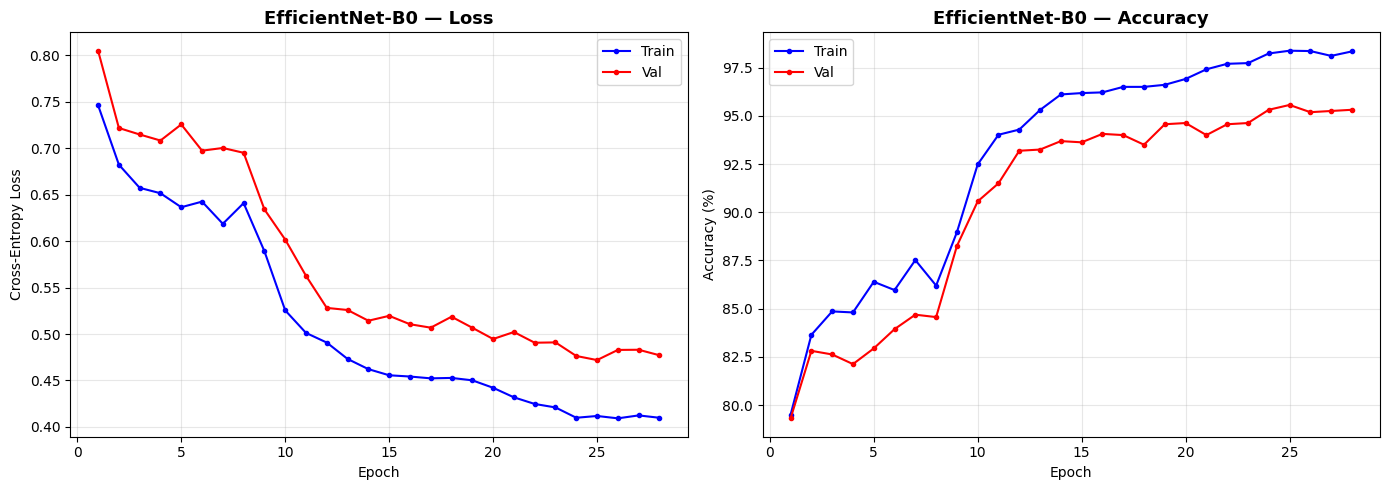

Saved: curves_efficientnet-b0.png


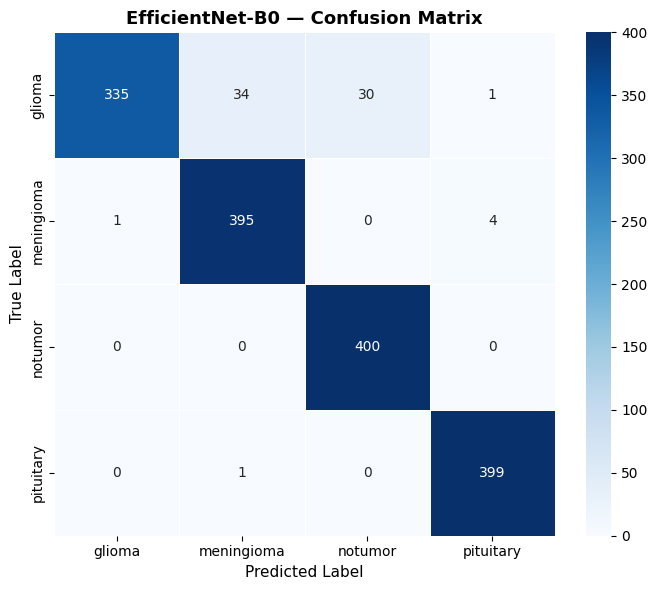

Saved: cm_efficientnet-b0.png

───────────────────────────────────────────────────────
  Results: EfficientNet-B0
───────────────────────────────────────────────────────
  Accuracy  : 95.56%
  Precision : 0.9584  (macro avg)
  Recall    : 0.9556  (macro avg)
  F1-Score  : 0.9546  (macro avg)

              precision    recall  f1-score   support

      glioma       1.00      0.84      0.91       400
  meningioma       0.92      0.99      0.95       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.95      1600
weighted avg       0.96      0.96      0.95      1600



In [10]:
plot_curves(history_effnet, 'EfficientNet-B0')
y_true_en, y_pred_en = evaluate_model(effnet)
plot_confusion_matrix(y_true_en, y_pred_en, 'EfficientNet-B0')
metrics_effnet = print_metrics(y_true_en, y_pred_en, 'EfficientNet-B0')

---
## Task 3 · Model Comparison & Ablation Table 

Full comparison of all four models across all four metrics.

In [26]:
all_metrics = [metrics_mlp, metrics_cnn, metrics_resnet, metrics_effnet]

# ── Ablation table ────────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  ABLATION TABLE — All Models")
print(f"{'='*72}")
print(f"  {'Model':<22} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>10}")
print(f"{'─'*72}")
for m in all_metrics:
    print(f"  {m['model']:<22} {m['accuracy']*100:>9.2f}%"
          f"  {m['precision']:>10.4f}  {m['recall']:>8.4f}  {m['f1']:>9.4f}")
print(f"{'='*72}")

best = max(all_metrics, key=lambda x: x['f1'])
print(f"\n  Best model: {best['model']}  (F1 = {best['f1']:.4f})")


  ABLATION TABLE — All Models
  Model                    Accuracy   Precision    Recall         F1
────────────────────────────────────────────────────────────────────────
  MLP Baseline               64.50%      0.6394    0.6450     0.6296
  Custom CNN                 79.31%      0.8135    0.7931     0.7877
  ResNet-18                  95.62%      0.9591    0.9563     0.9553
  EfficientNet-B0            95.56%      0.9584    0.9556     0.9546

  Best model: ResNet-18  (F1 = 0.9553)


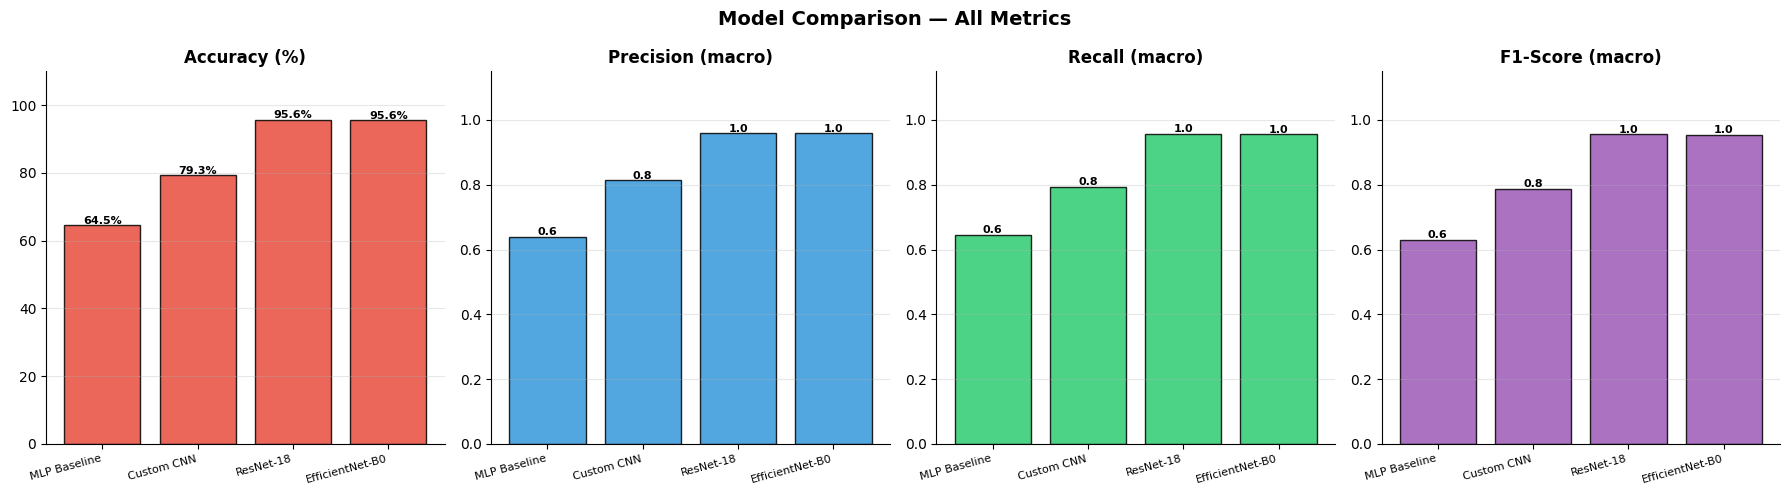

Saved: model_comparison.png


In [27]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
metric_keys   = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy (%)', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
bar_colors    = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
model_names   = [m['model'] for m in all_metrics]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, key, label, color in zip(axes, metric_keys, metric_labels, bar_colors):
    vals = [m[key] * (100 if key == 'accuracy' else 1) for m in all_metrics]
    bars = ax.bar(model_names, vals, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 110 if key == 'accuracy' else 1.15)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.5 if key == 'accuracy' else 0.005),
                f'{val:.1f}{"%" if key == "accuracy" else ""}',
                ha='center', fontsize=8, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

---
 Test-Time Augmentation (TTA)

**Idea:** At inference time, apply 10 different random augmentations of the  
same test image, average the 10 probability vectors, then take the argmax.

**Why it helps:** For borderline images near a decision boundary, averaging  
over multiple augmented views reduces the variance of the prediction.  
The cost is ~10× slower inference — worth it for evaluation, not production.

In [29]:
_tta_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])


def predict_tta(model: nn.Module, image_tensor: torch.Tensor,
                n_aug: int = 10) -> int:
    """
    TTA for a single image.

    Parameters
    ----------
    image_tensor : (1, 3, H, W) — already normalised, on CPU
    n_aug        : number of augmented views to average

    Returns
    -------
    Predicted class index (int)
    """
    model.eval()
    probs = torch.zeros(1, NUM_CLASSES).to(DEVICE)

    with torch.no_grad():
        # Original image
        probs += torch.softmax(model(image_tensor.to(DEVICE)), dim=1)
        # Augmented versions
        for _ in range(n_aug - 1):
            aug_img = _tta_transform(image_tensor)
            probs  += torch.softmax(model(aug_img.to(DEVICE)), dim=1)

    return (probs / n_aug).argmax(1).item()


def evaluate_with_tta(model: nn.Module, n_aug: int = 10):
    """Run TTA evaluation over the full test set."""
    y_true, y_pred = [], []
    for images, labels in tqdm(test_loader, desc=f'TTA (n={n_aug})'):
        for i in range(images.size(0)):
            y_pred.append(predict_tta(model, images[i:i+1], n_aug))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)


print("Running TTA on EfficientNet-B0 (n_aug=10) …")
print("(This takes ~5 min — each of the 1600 test images is predicted 10 times)")
y_true_tta, y_pred_tta = evaluate_with_tta(effnet, n_aug=10)
metrics_tta = print_metrics(y_true_tta, y_pred_tta, 'EfficientNet-B0 + TTA')

delta = (metrics_tta['accuracy'] - metrics_effnet['accuracy']) * 100
print(f"\n  Without TTA : {metrics_effnet['accuracy']*100:.2f}%")
print(f"  With    TTA : {metrics_tta['accuracy']*100:.2f}%")
print(f"  Improvement : {delta:+.2f} percentage points")

Running TTA on EfficientNet-B0 (n_aug=10) …
(This takes ~5 min — each of the 1600 test images is predicted 10 times)


TTA (n=10): 100%|██████████████████████████████████████████████████████████████████████| 50/50 [09:33<00:00, 11.48s/it]


───────────────────────────────────────────────────────
  Results: EfficientNet-B0 + TTA
───────────────────────────────────────────────────────
  Accuracy  : 95.62%
  Precision : 0.9590  (macro avg)
  Recall    : 0.9563  (macro avg)
  F1-Score  : 0.9553  (macro avg)

              precision    recall  f1-score   support

      glioma       0.99      0.84      0.91       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600


  Without TTA : 95.56%
  With    TTA : 95.62%
  Improvement : +0.06 percentage points


# import pickle

# ── Save training histories ────────────────────────────────────────────────────
histories = {
    'MLP Baseline':    history_mlp,
    'Custom CNN':      history_cnn,
    'ResNet-18':       history_resnet,
    'EfficientNet-B0': history_effnet,
}
with open('training_histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

# ── Save predictions ──────────────────────────────────────────────────────────
predictions = {
    'MLP Baseline':       (y_true_mlp.tolist(), y_pred_mlp.tolist()),
    'Custom CNN':         (y_true_cnn.tolist(), y_pred_cnn.tolist()),
    'ResNet-18':          (y_true_rn.tolist(),  y_pred_rn.tolist()),
    'EfficientNet-B0':    (y_true_en.tolist(),  y_pred_en.tolist()),
    'EfficientNet + TTA': (y_true_tta.tolist(), y_pred_tta.tolist()),
}
with open('predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# ── Final metrics including TTA ───────────────────────────────────────────────
all_metrics_final = all_metrics + [metrics_tta]
with open('all_metrics.json', 'w') as f:
    json.dump(all_metrics_final, f, indent=2)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  FINAL RESULTS SUMMARY")
print("="*65)
print(f"  {'Model':<28} {'Accuracy':>10}")
print("─"*65)
for m in all_metrics_final:
    marker = " ← best" if m == max(all_metrics_final, key=lambda x: x['accuracy']) else ""
    print(f"  {m['model']:<28} {m['accuracy']*100:>9.2f}%{marker}")
print("="*65)

print("\nSaved files:")
for f in ['training_histories.pkl', 'predictions.pkl', 'all_metrics.json',
          'model_comparison.png']:
    print(f"  {f}")
for name in ['MLP_Baseline', 'Custom_CNN', 'ResNet18', 'EfficientNet_B0']:
    print(f"  saved_models/{name}_best.pth")

print("\nCitations:")
print("  Dataset  : Kaggle — Brain Tumor MRI (Masoud Nickparvar, 2021)")
print("  ResNet   : He et al. (2016), Deep Residual Learning for Image Recognition")
print("  EffNet   : Tan & Le (2019), EfficientNet: Rethinking Model Scaling")
print("  Weights  : torchvision.models — ImageNet1K_V1")
print("  Framework: PyTorch", torch.__version__)